# 🌿 Leaf Disease Classification — MobileNetV2 FIXED v3
**Dataset:** 72 Kelas — `train/` + `valid/` + `test/`  
**Hardware:** NVIDIA GPU (CUDA)  

> **Perbaikan dari versi sebelumnya (anti-underfitting & anti-overfitting):**
> - ✅ **BUG FIX:** Augmentasi dipindah SEBELUM `preprocess_input` (bug kritis di versi lama)
> - ✅ **Head lebih ringan:** Dense 512 → 256 dihapus, cukup GAP → BN → Dense 512 → Dropout 0.3 → Softmax
> - ✅ **Dropout diturunkan** 0.5→0.3 di fase 1 (underfitting sebelumnya karena dropout terlalu besar)
> - ✅ **Peak LR diturunkan** 1e-3 → 5e-4 (lebih stabil untuk 72 kelas)
> - ✅ **Warmup diperpanjang** 3 → 5 epoch (konvergensi lebih smooth)
> - ✅ **Label smoothing diturunkan** 0.1 → 0.05 di fase 1 (tidak oversmooth saat model masih belajar)
> - ✅ **Fase 2:** partial unfreeze (hanya 50 layer terakhir) lebih aman dari full unfreeze
> - ✅ **AdamW** dengan weight_decay eksplisit menggantikan Adam biasa
> - ✅ **Augmentasi ditingkatkan:** tambah random_saturation & random_hue untuk variasi warna daun


In [1]:
import os, json, random, glob, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)


c:\Users\crism\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow : 2.10.1
Keras      : 2.10.0


## 1. Konfigurasi GPU (CUDA)

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

print("Logical devices:", tf.config.list_logical_devices())
print("CUDA built     :", tf.test.is_built_with_cuda())


✅ GPU: /physical_device:GPU:0
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
CUDA built     : True


## 2. Konfigurasi Path & Parameter

In [3]:
BASE_PATH  = r"C:\Users\crism\Music\80 10 10"
SAVE_DIR   = r"C:\Users\crism\Music\New folder (5)\final_output"
SAVE_MODEL = os.path.join(SAVE_DIR, "models")
SAVE_LABEL = os.path.join(SAVE_DIR, "labels")
os.makedirs(SAVE_MODEL, exist_ok=True)
os.makedirs(SAVE_LABEL, exist_ok=True)

TRAIN_DIR = os.path.join(BASE_PATH, "train")
VALID_DIR = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")

IMG_SIZE   = (256, 256)
IMG_SHAPE  = (256, 256, 3)
NUM_CLASSES = 72

# ✅ Batch 32 cukup — fokus pada kualitas gradient bukan kecepatan
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"IMG_SIZE   : {IMG_SIZE}")
for name, path in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    ok = "✅" if os.path.isdir(path) else "❌"
    print(f"  {ok} {name}: {path}")


BATCH_SIZE : 32
IMG_SIZE   : (256, 256)
  ✅ train: C:\Users\crism\Music\80 10 10\train
  ✅ valid: C:\Users\crism\Music\80 10 10\val
  ✅ test: C:\Users\crism\Music\80 10 10\test


## 2a. Preview Dataset — Gambar Asli (Belum Augmentasi)
> 8 gambar acak langsung dari disk, dibaca dengan `cv2` — belum disentuh preprocessing apapun.  
> Dipakai sebagai referensi visual sebelum masuk pipeline.

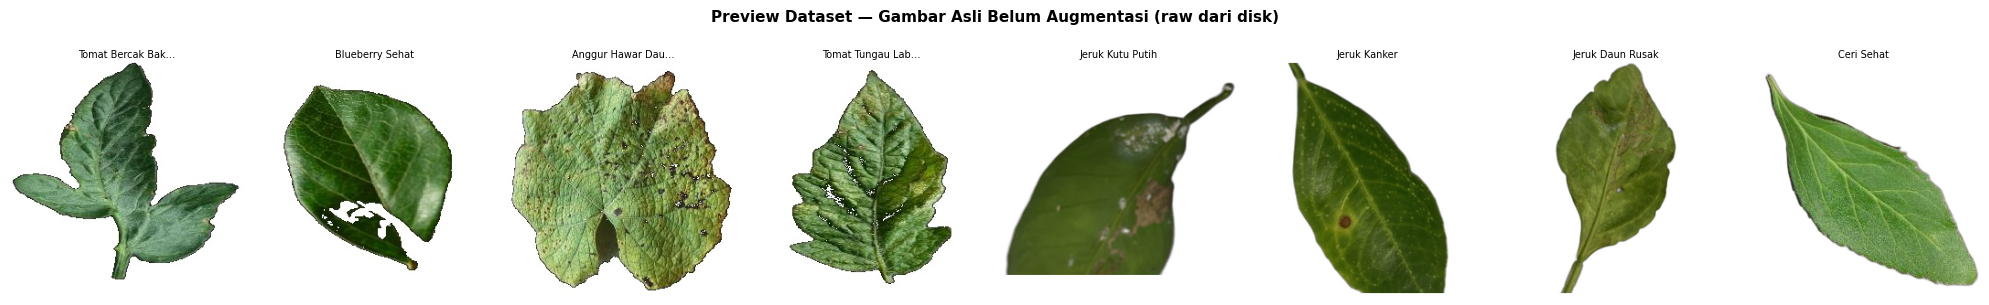

✅ Raw preview disimpan: C:\Users\crism\Music\New folder (5)\final_output\raw_preview.png


In [4]:
# ── Preview 8 Gambar Raw dari Disk ────────────────────────────────────────
N_RAW = 8

# Kumpulkan semua path gambar dari train dir
raw_all_paths = []
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        raw_all_paths.extend(glob.glob(os.path.join(cls_dir, ext)))

random.seed(SEED)
raw_sample = random.sample(raw_all_paths, N_RAW)

fig, axes = plt.subplots(1, N_RAW, figsize=(N_RAW * 2.5, 3.2))
fig.suptitle('Preview Dataset — Gambar Asli Belum Augmentasi (raw dari disk)',
             fontsize=11, fontweight='bold')

for i, path in enumerate(raw_sample):
    class_name = os.path.basename(os.path.dirname(path))
    short_name = class_name[:16] + '…' if len(class_name) > 16 else class_name

    # Baca langsung dari disk — belum ada preprocessing apapun
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    axes[i].imshow(img)
    axes[i].set_title(short_name, fontsize=7, pad=3)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'raw_preview.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Raw preview disimpan: {os.path.join(SAVE_DIR, 'raw_preview.png')}")


## 2b. Cek Distribusi ori_ vs aug_ (Opsional)
> Jalankan cell ini untuk melihat berapa banyak gambar ori_ dan aug_ di setiap split.  
> Pastikan val/ dan test/ **hanya berisi ori_**, bukan aug_.

In [5]:
from pathlib import Path

base_dir = Path(r"C:\Users\crism\Music\80 10 10")
image_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 90)
print("CHECK ORIGINAL vs AUGMENTATION")
print("=" * 90)

for split in ["train", "val", "test"]:
    split_dir = base_dir / split

    print(f"\n[{split.upper()}]")

    if not split_dir.exists():
        print("Folder tidak ditemukan.")
        continue

    total_ori = 0
    total_aug = 0

    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        ori = 0
        aug = 0
        other = 0

        for img in class_dir.iterdir():
            if img.suffix.lower() not in image_ext:
                continue

            name = img.stem.lower()

            if "ori_" in name:
                ori += 1
            elif "aug_" in name:
                aug += 1
            else:
                other += 1

        total_ori += ori
        total_aug += aug

        print(f"{class_dir.name:<25} ORI: {ori:5d} | AUG: {aug:5d} | OTHER: {other:5d}")

    print("-" * 90)
    print(f"TOTAL {split.upper():<10} ORI: {total_ori:5d} | AUG: {total_aug:5d}")

CHECK ORIGINAL vs AUGMENTATION

[TRAIN]
Anggur Busuk Hitam        ORI:   800 | AUG:     0 | OTHER:     0
Anggur Campak Hitam       ORI:   800 | AUG:     0 | OTHER:     0
Anggur Hawar Daun         ORI:   800 | AUG:     0 | OTHER:     0
Anggur Sehat              ORI:   800 | AUG:     0 | OTHER:     0
Apel Bercak Alternaria    ORI:   800 | AUG:     0 | OTHER:     0
Apel Bercak Cokelat       ORI:   800 | AUG:     0 | OTHER:     0
Apel Busuk Hitam          ORI:   800 | AUG:     0 | OTHER:     0
Apel Kudis                ORI:   800 | AUG:     0 | OTHER:     0
Apel Sehat                ORI:   800 | AUG:     0 | OTHER:     0
Blueberry Sehat           ORI:   800 | AUG:     0 | OTHER:     0
Ceri Embun Tepung         ORI:   800 | AUG:     0 | OTHER:     0
Ceri Sehat                ORI:   800 | AUG:     0 | OTHER:     0
Jagung Bercak Abu         ORI:   800 | AUG:     0 | OTHER:     0
Jagung Hawar Utara        ORI:   800 | AUG:     0 | OTHER:     0
Jagung Karat Daun         ORI:   800 | AUG:     0 

## 2c. Dataset Cleaner — Pindahkan aug_* ke train (Opsional)
> Jalankan cell ini **sekali** sebelum training untuk membersihkan dataset.  
> Set `DRY_RUN = True` terlebih dahulu untuk preview, lalu `False` untuk eksekusi.

In [6]:
"""
fix_dataset.py — Dataset Cleaner & Rebalancer
=============================================
Strategi:
  1. File aug_* di val/ & test/ → dipindah ke train/ (kelas yang sama)
  2. File ori_* tetap di val/ & test/
  3. Kelas yang ori_*-nya < TARGET di val/test → ambil ori_* dari train untuk mencukupi
  4. Setelah bersih, setiap kelas di val = TARGET_VAL gambar ori, test = TARGET_TEST gambar ori

Jalankan dengan: python fix_dataset.py
Lakukan DRY RUN dulu (DRY_RUN = True), lalu set False untuk eksekusi.
"""

import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

# ══════════════════════════════════════════════════════════════════════════════
# KONFIGURASI — SESUAIKAN PATH DI SINI
# ══════════════════════════════════════════════════════════════════════════════
BASE_PATH  = r"C:\Users\crism\Music\80 10 10"
TRAIN_DIR  = os.path.join(BASE_PATH, "train")
VAL_DIR    = os.path.join(BASE_PATH, "val")
TEST_DIR   = os.path.join(BASE_PATH, "test")

TARGET_VAL  = 204   # target jumlah ori per kelas di val
TARGET_TEST = 205   # target jumlah ori per kelas di test

SEED        = 42
DRY_RUN     = True  # ← set False untuk eksekusi sungguhan
# ══════════════════════════════════════════════════════════════════════════════

random.seed(SEED)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

def is_aug(filename):  return Path(filename).name.startswith('aug_')
def is_ori(filename):  return Path(filename).name.startswith('ori_')

def list_imgs(folder):
    return [f for f in Path(folder).iterdir()
            if f.suffix in IMG_EXTS and f.is_file()]

def move(src, dst, dry=True):
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dry:
        print(f"  [DRY] mv  {src.name}  →  {dst.parent.name}/")
    else:
        shutil.move(str(src), str(dst))

# ══════════════════════════════════════════════════════════════════════════════
# LANGKAH 1 & 2 — pindahkan aug_* dari val & test ke train
# ══════════════════════════════════════════════════════════════════════════════
def move_aug_to_train(split_dir, split_name):
    moved = 0
    classes = [d for d in Path(split_dir).iterdir() if d.is_dir()]
    for cls_dir in sorted(classes):
        aug_files = [f for f in list_imgs(cls_dir) if is_aug(f)]
        if not aug_files:
            continue
        dst_cls = Path(TRAIN_DIR) / cls_dir.name
        for f in aug_files:
            dst = dst_cls / f.name
            # hindari overwrite jika nama sama
            if dst.exists():
                dst = dst_cls / (f.stem + '_from_' + split_name + f.suffix)
            move(f, dst, DRY_RUN)
            moved += 1
        print(f"  {cls_dir.name}: {len(aug_files)} aug_ dipindah ke train/")
    return moved

print("=" * 65)
print("LANGKAH 1 — Pindah aug_* dari VAL ke TRAIN")
print("=" * 65)
n1 = move_aug_to_train(VAL_DIR,  'val')

print()
print("=" * 65)
print("LANGKAH 2 — Pindah aug_* dari TEST ke TRAIN")
print("=" * 65)
n2 = move_aug_to_train(TEST_DIR, 'test')

print(f"\nTotal aug_ dipindah ke train: {n1 + n2} file\n")

# ══════════════════════════════════════════════════════════════════════════════
# LANGKAH 3 — topup ori_* dari train jika val/test kurang dari target
# ══════════════════════════════════════════════════════════════════════════════
def topup_from_train(split_dir, split_name, target):
    print("=" * 65)
    print(f"LANGKAH 3 — Topup ori_* di {split_name.upper()} dari TRAIN (target/kelas = {target})")
    print("=" * 65)
    topup_total = 0
    classes = sorted([d.name for d in Path(split_dir).iterdir() if d.is_dir()])

    for cls_name in classes:
        split_cls = Path(split_dir) / cls_name
        train_cls = Path(TRAIN_DIR) / cls_name

        # ori yang sudah ada di split
        existing_ori = [f for f in list_imgs(split_cls) if is_ori(f)]
        have = len(existing_ori)
        need = target - have

        if need <= 0:
            print(f"  {cls_name}: sudah cukup ({have} ori) — skip")
            continue

        # ori yang tersedia di train (setelah aug_ sudah dipindah masuk, tapi kita ambil ori saja)
        train_ori = [f for f in list_imgs(train_cls) if is_ori(f)]

        if len(train_ori) == 0:
            print(f"  {cls_name}: ⚠️  tidak ada ori_ di train — tidak bisa topup!")
            continue

        if len(train_ori) < need:
            print(f"  {cls_name}: ⚠️  train hanya punya {len(train_ori)} ori, butuh {need} — ambil semua")
            to_move = train_ori
        else:
            to_move = random.sample(train_ori, need)

        for f in to_move:
            dst = split_cls / f.name
            move(f, dst, DRY_RUN)

        print(f"  {cls_name}: {have} → {have + len(to_move)} ori  (ambil {len(to_move)} dari train)")
        topup_total += len(to_move)

    print(f"\nTotal file ditopup ke {split_name}: {topup_total}\n")
    return topup_total

n3 = topup_from_train(VAL_DIR,  'val',  TARGET_VAL)
n4 = topup_from_train(TEST_DIR, 'test', TARGET_TEST)

# ══════════════════════════════════════════════════════════════════════════════
# VERIFIKASI AKHIR
# ══════════════════════════════════════════════════════════════════════════════
def verify(split_dir, split_name):
    print("=" * 65)
    print(f"VERIFIKASI {split_name.upper()}")
    print("=" * 65)
    total_ori = 0
    total_aug = 0
    issues = []
    for cls_dir in sorted(Path(split_dir).iterdir()):
        if not cls_dir.is_dir(): continue
        imgs  = list_imgs(cls_dir)
        ori_n = sum(1 for f in imgs if is_ori(f))
        aug_n = sum(1 for f in imgs if is_aug(f))
        total_ori += ori_n
        total_aug += aug_n
        if aug_n > 0:
            issues.append(f"  ⚠️  {cls_dir.name}: masih ada {aug_n} aug_")
        print(f"  {cls_dir.name:<35} ori={ori_n:>4}  aug={aug_n:>4}")
    print(f"\n  TOTAL ori={total_ori}  aug={total_aug}")
    if issues:
        print("\n  MASALAH:")
        for i in issues: print(i)
    else:
        print("  ✅ Tidak ada aug_ tersisa")
    return total_ori, total_aug

if not DRY_RUN:
    verify(VAL_DIR,  'val')
    verify(TEST_DIR, 'test')

print()
if DRY_RUN:
    print("╔══════════════════════════════════════════════════════════════╗")
    print("║  DRY RUN selesai — tidak ada file yang dipindah sungguhan   ║")
    print("║  Kalau hasilnya sesuai, set DRY_RUN = False lalu jalankan   ║")
    print("╚══════════════════════════════════════════════════════════════╝")
else:
    print("✅ Selesai! Dataset sudah bersih.")
    print("   val  → ori saja")
    print("   test → ori saja")
    print("   train → ori + aug (termasuk aug_ dari val/test yang dipindah)")

LANGKAH 1 — Pindah aug_* dari VAL ke TRAIN

LANGKAH 2 — Pindah aug_* dari TEST ke TRAIN

Total aug_ dipindah ke train: 0 file

LANGKAH 3 — Topup ori_* di VAL dari TRAIN (target/kelas = 204)
  [DRY] mv  ori_00955.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00167.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00038.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_01115.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00399.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00362.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00320.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00206.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_01108.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00153.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_01010.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_01114.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00814.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00130.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00884.jpg  →  Anggur Busuk Hitam/
  [DRY] mv  ori_00637.jpg  →  Anggur Busuk Hitam/
  [DRY] mv

## 3. tf.data Pipeline
> **Augmentasi on-the-fly DIAKTIFKAN** — augmentasi dilakukan secara dinamis setiap epoch di pipeline training.  
> Ini mencegah model bias karena setiap epoch model melihat variasi gambar yang berbeda-beda.  
> Val & test **tidak diaugmentasi** — hanya `load → resize → preprocess_input [-1,1]` untuk evaluasi yang fair.  
> Augmentasi dilakukan pada pixel `[0,255]` **SEBELUM** `preprocess_input` (urutan ini krusial — bug versi lama).

In [7]:
# ── Rotation layer (dibuat sekali di luar @tf.function agar serializable) ────
rotation_layer = tf.keras.layers.RandomRotation(
    factor=0.1,           # ±36 derajat  (0.1 × 360°)
    fill_mode="reflect",
    seed=SEED
)

# ── Load & decode satu gambar dari disk ──────────────────────────────────────
def load_image(path, label):
    """Baca gambar dari disk → float32 [0,255], resize ke IMG_SIZE."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.cast(image, tf.float32)          # uint8 → float32 [0,255]
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

# ── Augmentasi on-the-fly (train only) ───────────────────────────────────────
@tf.function
def augment_train(image, label):
    """
    Augmentasi on-the-fly.
    Input  : float32 [0,255]
    Output : preprocess_input() → [-1,1]
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2 * 255)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.7, upper=1.3)
    image = tf.image.random_hue(image, max_delta=0.05)

    crop_frac = tf.random.uniform([], 0.85, 1.0)
    crop_h    = tf.cast(tf.cast(IMG_SIZE[0], tf.float32) * crop_frac, tf.int32)
    crop_w    = tf.cast(tf.cast(IMG_SIZE[1], tf.float32) * crop_frac, tf.int32)
    image     = tf.image.random_crop(image, size=[crop_h, crop_w, 3])
    image     = tf.image.resize(image, IMG_SIZE)

    # rotation_layer dibuat di luar @tf.function → aman dipanggil di sini
    image = rotation_layer(tf.expand_dims(image, 0), training=True)[0]

    image = tf.clip_by_value(image, 0., 255.)
    image = preprocess_input(image)
    return image, label

# ── Preprocess val/test (tanpa augmentasi) ───────────────────────────────────
@tf.function
def preprocess_eval(image, label):
    image = preprocess_input(image)
    return image, label

# ── One-hot encode label ──────────────────────────────────────────────────────
def one_hot(image, label):
    return image, tf.one_hot(label, NUM_CLASSES)

# ── Build tf.data dari directory ─────────────────────────────────────────────
def build_dataset(directory, augment=False, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=None,          # unbatched — augmentasi per-sample
        shuffle=shuffle,
        seed=SEED,
        label_mode="int"
    )
    # Ambil class_names & indices dari dataset train (hanya sekali)
    return ds

# Bangun dataset mentah dulu untuk ambil class info
_raw_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=True,
    seed=SEED, label_mode="int"
)
class_names   = _raw_train.class_names
class_indices = {name: i for i, name in enumerate(class_names)}
print(f"Jumlah kelas terdeteksi: {len(class_names)}")
assert len(class_names) == NUM_CLASSES, \
    f"Kelas terdeteksi {len(class_names)} ≠ NUM_CLASSES={NUM_CLASSES}"

# Kumpulkan label untuk class-weight
train_labels = []
for _, lbl in _raw_train:
    train_labels.append(lbl.numpy())
train_labels = np.array(train_labels)
print(f"Total sampel train : {len(train_labels)}")

# ── Pipeline train ────────────────────────────────────────────────────────────
train_ds = (
    _raw_train
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(augment_train, num_parallel_calls=AUTOTUNE)
    .map(one_hot,       num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Pipeline valid ────────────────────────────────────────────────────────────
_raw_valid = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=False,
    seed=SEED, label_mode="int"
)
valid_ds = (
    _raw_valid
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .map(one_hot,         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Pipeline test ─────────────────────────────────────────────────────────────
_raw_test = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=False,
    seed=SEED, label_mode="int"
)
test_ds = (
    _raw_test
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .map(one_hot,         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("\n✅ Semua pipeline siap.")
print(f"  train_ds : {train_ds}")
print(f"  valid_ds : {valid_ds}")
print(f"  test_ds  : {test_ds}")


Found 57682 files belonging to 72 classes.
Jumlah kelas terdeteksi: 72
Total sampel train : 57682
Found 7158 files belonging to 72 classes.
Found 7160 files belonging to 72 classes.

✅ Semua pipeline siap.
  train_ds : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>
  valid_ds : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>
  test_ds  : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>


## 4. Visualisasi Augmentasi — Sebelum vs Sesudah
> **Sebelum:** gambar raw setelah `load_image` (pixel [0,255], belum disentuh apapun)  
> **Sesudah:** gambar setelah `augment_train` → `preprocess_input`, lalu di-denormalisasi kembali ke [0,255] untuk ditampilkan  
> Ini adalah preview augmentasi on-the-fly yang akan dijalankan setiap epoch saat training.  
> Tampil 8 gambar acak dari train set.

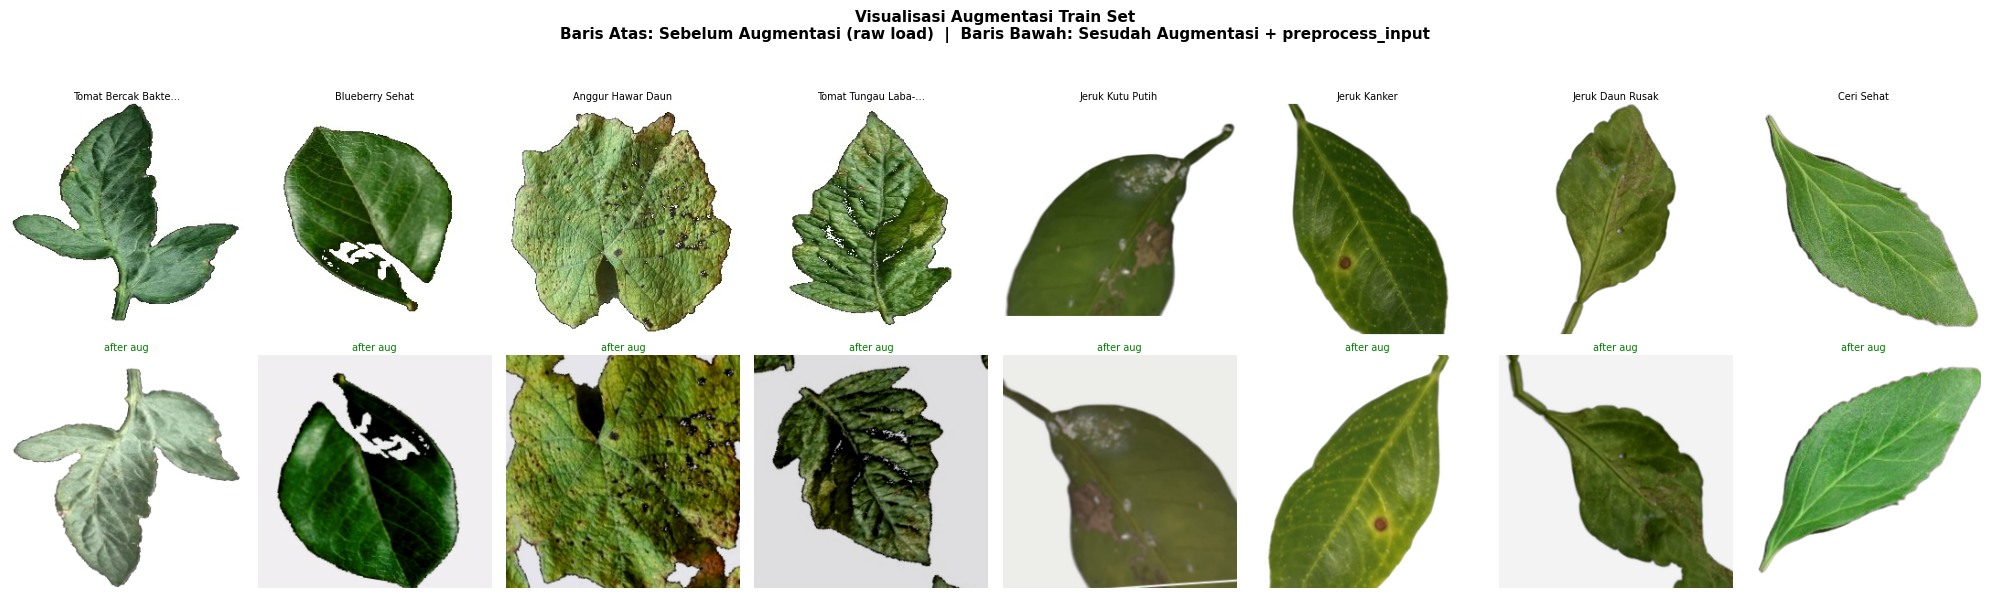

✅ Preview disimpan: C:\Users\crism\Music\New folder (5)\final_output\augmentation_preview.png


In [8]:
# ── Visualisasi Augmentasi: Sebelum vs Sesudah ────────────────────────────
N_VIS = 8  # jumlah gambar yang ditampilkan

# Kumpulkan semua path gambar dari train set
all_train_paths = []
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        all_train_paths.extend(glob.glob(os.path.join(cls_dir, ext)))

# Ambil N_VIS gambar acak
random.seed(SEED)
sample_paths = random.sample(all_train_paths, N_VIS)

# ── Helper: denormalisasi dari [-1,1] ke [0,255] untuk ditampilkan ────────
def denormalize_mobilenet(img_tensor):
    """Balik preprocess_input MobileNetV2: [-1,1] → [0,255]."""
    img = img_tensor.numpy() if hasattr(img_tensor, 'numpy') else img_tensor
    img = (img + 1.0) * 127.5
    return np.clip(img, 0, 255).astype(np.uint8)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N_VIS, figsize=(N_VIS * 2.5, 6))
fig.suptitle('Visualisasi Augmentasi Train Set\n'
             'Baris Atas: Sebelum Augmentasi (raw load)  |  '
             'Baris Bawah: Sesudah Augmentasi + preprocess_input',
             fontsize=11, fontweight='bold', y=1.02)

for i, path in enumerate(sample_paths):
    class_name = os.path.basename(os.path.dirname(path))
    short_name = class_name[:18] + '…' if len(class_name) > 18 else class_name

    # ── SEBELUM: load_image saja (pixel [0,255]) ──────────────────────────
    dummy_label = tf.zeros(NUM_CLASSES)
    img_raw, _ = load_image(path, dummy_label)
    img_before = img_raw.numpy().astype(np.uint8)

    # ── SESUDAH: augment_train → preprocess_input, lalu denormalize ───────
    img_aug, _ = augment_train(img_raw, dummy_label)
    img_after  = denormalize_mobilenet(img_aug)

    # Tampilkan
    axes[0, i].imshow(img_before)
    axes[0, i].set_title(f'{short_name}', fontsize=7, pad=3)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_after)
    axes[1, i].set_title('after aug', fontsize=7, pad=3, color='green')
    axes[1, i].axis('off')

# Label baris
axes[0, 0].set_ylabel('Sebelum\n(raw load)', fontsize=9, color='steelblue',
                       rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Sesudah\n(aug+preproc)', fontsize=9, color='green',
                       rotation=90, labelpad=5)
for ax in axes.flat:
    ax.set_visible(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'augmentation_preview.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Preview disimpan: {os.path.join(SAVE_DIR, 'augmentation_preview.png')}")


## 5. Class Weights (Imbalance Handling)


In [9]:
unique_labels = np.unique(train_labels)
calc_weights  = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train_labels
)
class_weights_dict = {int(k): float(min(v, 5.0)) for k, v in zip(unique_labels, calc_weights)}
print(f"Class weights ({len(class_weights_dict)} kelas) — clipped at 5.0")
w_vals = list(class_weights_dict.values())
print(f"  min={min(w_vals):.4f} | max={max(w_vals):.4f} | mean={np.mean(w_vals):.4f}")


Class weights (72 kelas) — clipped at 5.0
  min=0.9083 | max=1.0014 | mean=1.0001


## 6. Arsitektur Model — MobileNetV2 + Head Lebih Ringan
> **Perubahan head (anti-underfitting):**  
> - Head lama: GAP → BN → Dense(512) → Dropout(0.5) → Dense(256) → Dropout(0.4) → Softmax  
> - Head baru: GAP → BN → Dense(512) → Dropout(0.3) → Softmax  
> - **Mengapa?** Dropout 0.5 + dua Dense layer dalam buat model sulit konvergen saat base frozen.  
>   Val acc > train acc di versi lama adalah tanda klasik underfitting akibat regularisasi berlebih.
> - **AdamW** dengan weight_decay eksplisit (lebih benar dari Adam + L2)

In [10]:
# ============================================================
# Mirrored Strategy
# ============================================================

strategy = tf.distribute.MirroredStrategy()
print(f"Jumlah device: {strategy.num_replicas_in_sync}")

# ============================================================
# Optimizer (TensorFlow 2.10 Compatible)
# ============================================================

try:
    # TensorFlow 2.10
    from tensorflow.keras.optimizers.experimental import AdamW

    optimizer = AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    )

    print("Optimizer : AdamW (experimental)")

except Exception:

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3
    )

    print("Optimizer : Adam")

# ============================================================
# Build Model
# ============================================================

with strategy.scope():

    def build_model(num_classes):

        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SHAPE
        )

        # Phase-1 : Freeze backbone
        base_model.trainable = False

        inputs = base_model.input

        x = base_model.output
        x = layers.GlobalAveragePooling2D()(x)

        x = layers.BatchNormalization()(x)

        x = layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-5),  # diturunkan dari 1e-4 -> kontribusi ke val_loss lebih kecil
            name="feature_dense"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Dropout(0.30)(x)

        outputs = layers.Dense(
            num_classes,
            activation="softmax",
            name="predictions"
        )(x)

        return models.Model(inputs, outputs)

    model = build_model(NUM_CLASSES)

    # Loss
    loss_fn_p1 = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.02  # diturunkan dari 0.05 -> floor loss teoritis turun dari ~0.41 ke ~0.18
    )

    # Compile
    model.compile(
        optimizer=optimizer,
        loss=loss_fn_p1,
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="accuracy")
        ]
    )

# ============================================================
# Model Summary
# ============================================================

trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
nontrainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("=" * 60)
print(f"Total trainable params     : {trainable:,}")
print(f"Total non-trainable params : {nontrainable:,}")
print("=" * 60)

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Jumlah device: 1
Optimizer : AdamW (experimental)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:ten

## 7. Cosine Annealing LR dengan Warmup
> **Perubahan:**
> - Peak LR diturunkan 1e-3 → **5e-4** (lebih stabil untuk 72 kelas, gradient tidak meledak)
> - Warmup diperpanjang 3 → **5 epoch** (konvergensi lebih smooth, loss tidak spike)

In [11]:
class WarmupCosineDecay(callbacks.Callback):
    """LR naik linear saat warmup, lalu turun cosine hingga min_lr."""
    def __init__(self, total_epochs, warmup_epochs=5,
                 start_lr=1e-5, peak_lr=5e-4, min_lr=1e-6):
        super().__init__()
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs
        self.start_lr      = start_lr
        self.peak_lr       = peak_lr
        self.min_lr        = min_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.peak_lr - self.start_lr) * (epoch / self.warmup_epochs)
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                1 + math.cos(math.pi * progress))
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
        print(f"  [LR] Epoch {epoch+1}: lr = {lr:.2e}")

print("WarmupCosineDecay callback siap.")


WarmupCosineDecay callback siap.


## 8. Callbacks

In [12]:
EPOCHS_PHASE1 = 40
EPOCHS_PHASE2 = 25  # ✅ Diperpanjang karena partial unfreeze butuh lebih banyak epoch

cb_phase1 = [
    WarmupCosineDecay(
        total_epochs=EPOCHS_PHASE1,
        warmup_epochs=5,      # ✅ Warmup lebih panjang dari 3 → 5
        start_lr=1e-5,
        peak_lr=5e-4,         # ✅ Peak diturunkan 1e-3 → 5e-4
        min_lr=1e-6
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        os.path.join(SAVE_MODEL, "phase1_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

cb_phase2 = [
    WarmupCosineDecay(
        total_epochs=EPOCHS_PHASE2,
        warmup_epochs=3,
        start_lr=1e-7,
        peak_lr=2e-5,         # ✅ Sedikit lebih tinggi dari 1e-5 untuk partial unfreeze
        min_lr=1e-7
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        os.path.join(SAVE_MODEL, "phase2_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks siap.")
print(f"  Phase 1: max {EPOCHS_PHASE1} epoch, LR peak 5e-4, warmup 5 epoch")
print(f"  Phase 2: max {EPOCHS_PHASE2} epoch, LR peak 2e-5 (partial fine-tune)")


Callbacks siap.
  Phase 1: max 40 epoch, LR peak 5e-4, warmup 5 epoch
  Phase 2: max 25 epoch, LR peak 2e-5 (partial fine-tune)


## 9. Fase 1 — Feature Extraction (Base Frozen)
> Hanya head yang dilatih. Dengan perbaikan augmentasi dan dropout lebih rendah,  
> train acc seharusnya mendekati atau melewati val acc (bukan jauh di bawahnya seperti sebelumnya).

In [13]:
print("=" * 60)
print("FASE 1: Feature Extraction — Base Model FROZEN")
print("=" * 60)

if tf.config.list_physical_devices('GPU'):
    print(f"✅ GPU: {tf.config.list_physical_devices('GPU')[0].name}")

history_phase1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=cb_phase1,
    class_weight=class_weights_dict
)


FASE 1: Feature Extraction — Base Model FROZEN
✅ GPU: /physical_device:GPU:0
  [LR] Epoch 1: lr = 1.00e-05
Epoch 1/40
1803/1803 [==============================] - ETA: 0s - loss: 3.4337 - accuracy: 0.2275
Epoch 1: val_accuracy improved from -inf to 0.51900, saving model to C:\Users\crism\Music\New folder (5)\final_output\models\phase1_best.keras
1803/1803 [==============================] - 183s 93ms/step - loss: 3.4337 - accuracy: 0.2275 - val_loss: 2.0034 - val_accuracy: 0.5190
  [LR] Epoch 2: lr = 1.08e-04
Epoch 2/40
1802/1803 [============================>.] - ETA: 0s - loss: 1.1415 - accuracy: 0.7244
Epoch 2: val_accuracy improved from 0.51900 to 0.83501, saving model to C:\Users\crism\Music\New folder (5)\final_output\models\phase1_best.keras
1803/1803 [==============================] - 164s 90ms/step - loss: 1.1413 - accuracy: 0.7244 - val_loss: 0.7558 - val_accuracy: 0.8350
  [LR] Epoch 3: lr = 2.06e-04
Epoch 3/40
1802/1803 [============================>.] - ETA: 0s - loss: 0.74

## 10. Grafik Fase 1
> **Tanda healthy training:**
> - Train acc harus ≥ val acc (jika masih jauh di bawah, ada underfitting)
> - Gap train-val tidak terlalu besar (< 5% normal, > 10% overfitting)

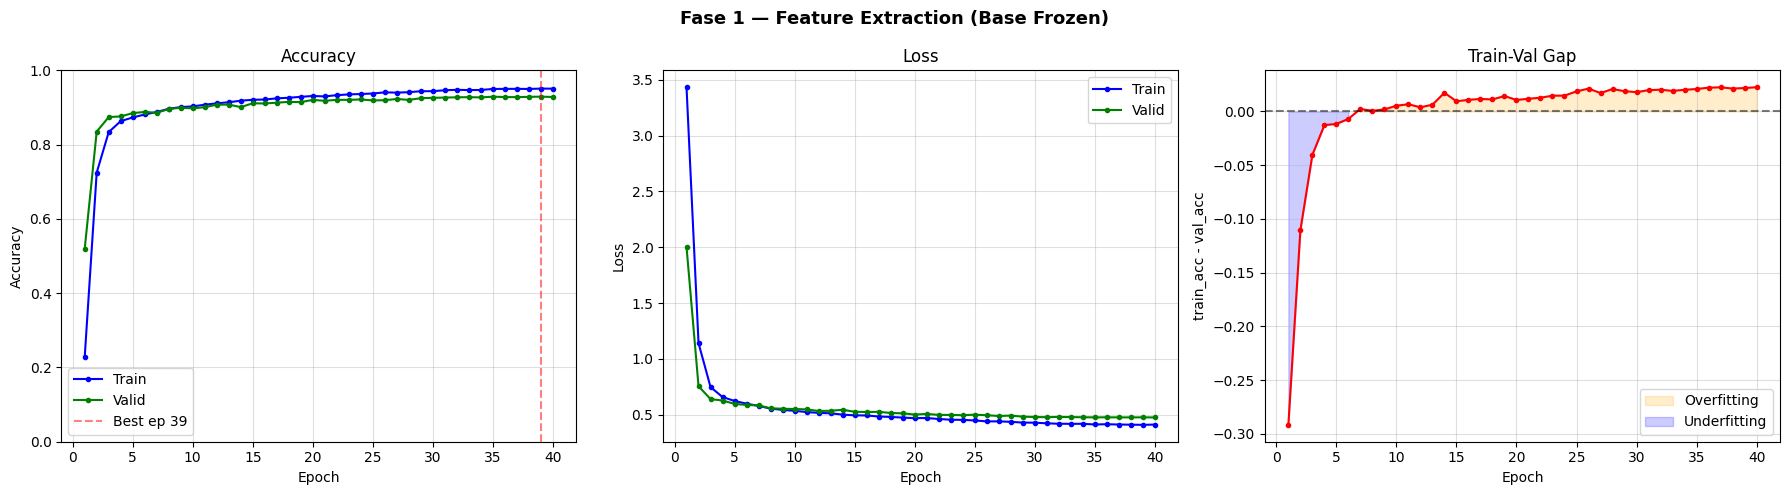

Best val_acc : 0.9292 @ epoch 39
Final gap    : +0.0225 (OK)


In [14]:
def plot_history(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    ep       = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(ep, acc,     'b-o', ms=3, label='Train')
    axes[0].plot(ep, val_acc, 'g-o', ms=3, label='Valid')
    best_e = int(np.argmax(val_acc)) + 1
    axes[0].axvline(best_e, color='r', linestyle='--', alpha=0.5, label=f'Best ep {best_e}')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    axes[0].legend(); axes[0].grid(True, alpha=0.4)

    # Loss
    axes[1].plot(ep, loss,     'b-o', ms=3, label='Train')
    axes[1].plot(ep, val_loss, 'g-o', ms=3, label='Valid')
    axes[1].set(title='Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

    # Gap (train - val) — monitor overfitting
    gap = [a - v for a, v in zip(acc, val_acc)]
    axes[2].plot(ep, gap, 'r-o', ms=3)
    axes[2].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[2].fill_between(ep, gap, 0,
                         where=[g > 0 for g in gap], alpha=0.2, color='orange', label='Overfitting')
    axes[2].fill_between(ep, gap, 0,
                         where=[g < 0 for g in gap], alpha=0.2, color='blue', label='Underfitting')
    axes[2].set(title='Train-Val Gap', xlabel='Epoch', ylabel='train_acc - val_acc')
    axes[2].legend(); axes[2].grid(True, alpha=0.4)

    plt.tight_layout(); plt.show()
    print(f"Best val_acc : {max(val_acc):.4f} @ epoch {best_e}")
    print(f"Final gap    : {gap[-1]:+.4f} ({'overfit' if gap[-1] > 0.05 else 'underfit' if gap[-1] < -0.02 else 'OK'})")

plot_history(history_phase1, "Fase 1 — Feature Extraction (Base Frozen)")


## 11. Evaluasi TEST SET — Sebelum Fine Tuning

Evaluasi TEST SET — Sebelum Fine Tuning
224/224 [==============================] - 14s 55ms/step

Test Accuracy (sebelum fine-tune): 0.9299

                               precision    recall  f1-score   support

           Anggur Busuk Hitam     0.9600    0.9600    0.9600       100
          Anggur Campak Hitam     0.9604    0.9700    0.9652       100
            Anggur Hawar Daun     0.9802    0.9900    0.9851       100
                 Anggur Sehat     1.0000    1.0000    1.0000       100
       Apel Bercak Alternaria     0.9143    0.9600    0.9366       100
          Apel Bercak Cokelat     0.9706    0.9900    0.9802       100
             Apel Busuk Hitam     1.0000    0.9800    0.9899       100
                   Apel Kudis     0.9891    0.9100    0.9479       100
                   Apel Sehat     0.9151    0.9700    0.9417       100
              Blueberry Sehat     0.9505    0.9600    0.9552       100
            Ceri Embun Tepung     1.0000    1.0000    1.0000       100
      

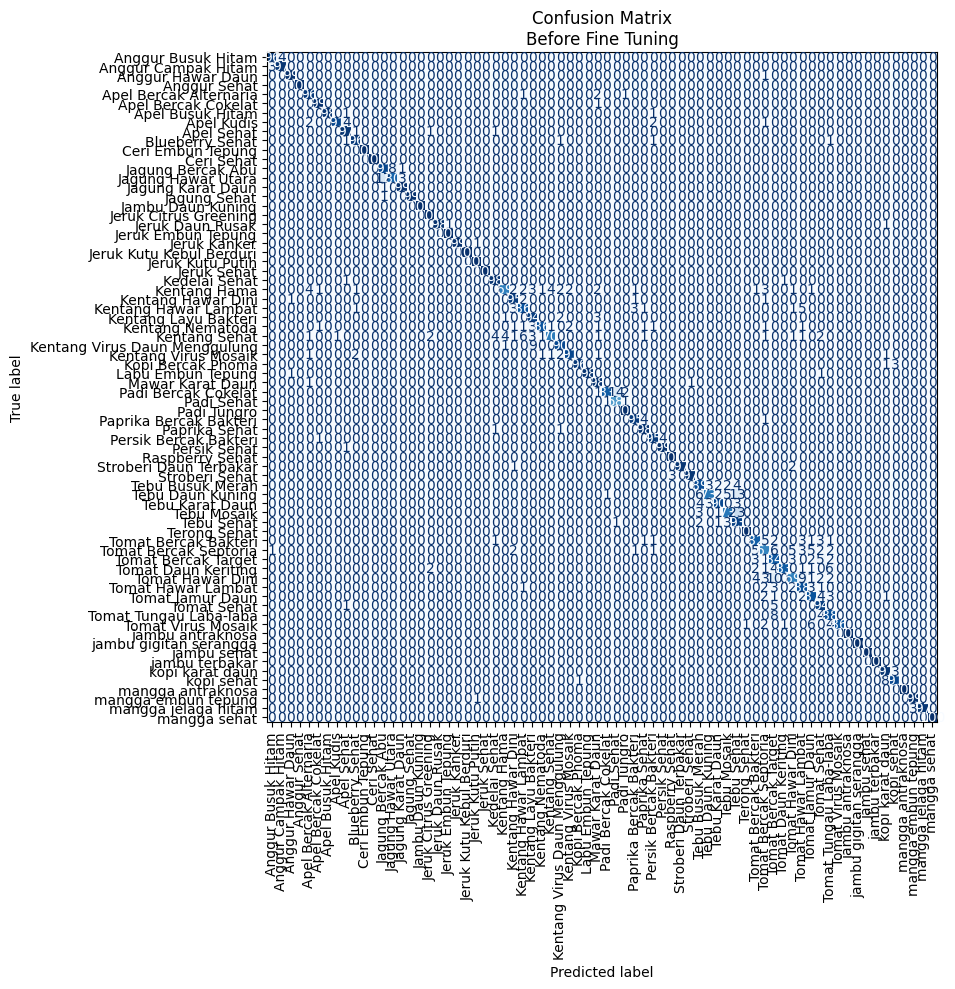

SEMUA HASIL BERHASIL DISIMPAN
Accuracy           : 0.9298882681564246
TXT Report         : C:\Users\crism\Music\New folder (5)\final_output\classification_report_before_finetune.txt
CSV Report         : C:\Users\crism\Music\New folder (5)\final_output\classification_report_before_finetune.csv
Confusion Matrix   : C:\Users\crism\Music\New folder (5)\final_output\confusion_matrix_before_finetune.png
Accuracy TXT       : C:\Users\crism\Music\New folder (5)\final_output\test_accuracy_before_finetune.txt


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

print('=' * 60)
print('Evaluasi TEST SET — Sebelum Fine Tuning')
print('=' * 60)

# ------------------------------------------------------------
# Prediksi
# ------------------------------------------------------------
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Ground Truth
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------
acc_before = np.mean(y_true == y_pred)
print(f'\nTest Accuracy (sebelum fine-tune): {acc_before:.4f}\n')

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# ============================================================
# Simpan Classification Report (.txt)
# ============================================================
os.makedirs(SAVE_DIR, exist_ok=True)

txt_path = os.path.join(SAVE_DIR, 'classification_report_before_finetune.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('TEST SET - BEFORE FINE TUNING\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Accuracy : {acc_before:.4f}\n\n')
    f.write(report)

# ============================================================
# Simpan Accuracy
# ============================================================
acc_path = os.path.join(SAVE_DIR, 'test_accuracy_before_finetune.txt')
with open(acc_path, 'w') as f:
    f.write(f'Accuracy = {acc_before:.6f}')

# ============================================================
# Simpan Classification Report CSV
# ============================================================
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
csv_path  = os.path.join(SAVE_DIR, 'classification_report_before_finetune.csv')
df_report.to_csv(csv_path)

# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax, colorbar=False)
plt.title('Confusion Matrix\nBefore Fine Tuning')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, 'confusion_matrix_before_finetune.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Informasi File
# ============================================================
print('=' * 60)
print('SEMUA HASIL BERHASIL DISIMPAN')
print('=' * 60)
print('Accuracy           :', acc_before)
print('TXT Report         :', txt_path)
print('CSV Report         :', csv_path)
print('Confusion Matrix   :', cm_path)
print('Accuracy TXT       :', acc_path)


## 12. Fase 2 — Partial Fine Tuning (50 Layer Terakhir)
> **Perubahan penting dari versi lama:**  
> - **Versi lama:** unfreeze SEMUA layer → rentan catastrophic forgetting, LR harus sangat kecil  
> - **Versi baru:** hanya unfreeze **50 layer terakhir** MobileNetV2 (high-level feature layers)  
> - Ini lebih aman, konvergensi lebih cepat, dan sering menghasilkan akurasi lebih tinggi  
> - BatchNorm tetap frozen untuk stabilitas inference
> - Label smoothing dinaikkan ke 0.1 di fase 2 untuk mencegah overfit saat fine-tuning

## 12 A. Fine Tuning Setup + Compile

In [16]:
from tensorflow.keras.optimizers.experimental import AdamW

print("=" * 60)
print("FASE 2 : Partial Fine Tuning (50 Layer Terakhir)")
print("=" * 60)

# ==========================================================
# Cari layer terakhir MobileNetV2
# ==========================================================
last_base_idx = None

for i, layer in enumerate(model.layers):
    if layer.name == "out_relu":
        last_base_idx = i
        break

if last_base_idx is None:
    raise ValueError("Layer 'out_relu' tidak ditemukan!")

mobilenet_layer_count = last_base_idx + 1
fine_tune_at = max(0, mobilenet_layer_count - 50)

# ==========================================================
# Freeze semua layer
# ==========================================================
for layer in model.layers:
    layer.trainable = False

# ==========================================================
# Buka 50 layer terakhir MobileNetV2
# ==========================================================
for i in range(fine_tune_at, mobilenet_layer_count):

    layer = model.layers[i]

    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# ==========================================================
# Head classifier tetap trainable
# ==========================================================
for layer in model.layers[mobilenet_layer_count:]:

    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# ==========================================================
# Statistik
# ==========================================================
trainable_params = np.sum(
    [tf.keras.backend.count_params(w) for w in model.trainable_weights]
)

non_trainable_params = np.sum(
    [tf.keras.backend.count_params(w) for w in model.non_trainable_weights]
)

print(f"MobileNetV2 total layer : {mobilenet_layer_count}")
print(f"Fine-tune mulai layer   : {fine_tune_at}")
print(f"Layer terakhir backbone : {last_base_idx}")
print(f"Trainable Params        : {trainable_params:,}")
print(f"Non Trainable Params    : {non_trainable_params:,}")

print("=" * 60)

with strategy.scope():
    model.compile(
        optimizer=AdamW(
            learning_rate=2e-5,
            weight_decay=1e-4
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.02  # disamakan dgn Fase 1, sebelumnya 0.1 (floor loss ~0.74!)
        ),
        metrics=["accuracy"]
    )

print("✓ Model siap untuk Fine Tuning")

FASE 2 : Partial Fine Tuning (50 Layer Terakhir)
MobileNetV2 total layer : 154
Fine-tune mulai layer   : 104
Layer terakhir backbone : 153
Trainable Params        : 2,527,240
Non Trainable Params    : 430,720
✓ Model siap untuk Fine Tuning


## 12 B. TRAINING FINE TUNING

In [17]:
# ==========================================================
# Callback Simpan Model Terbaik
# ==========================================================
checkpoint_phase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath="mobilenetv2_phase2_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Gabungkan callback lama dengan checkpoint
callbacks_phase2 = cb_phase2 + [checkpoint_phase2]

print("=" * 60)
print("Mulai Fine Tuning...")
print("=" * 60)

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
    class_weight=class_weights_dict,
    verbose=1
)

# ==========================================================
# Simpan model terakhir
# ==========================================================
model.save("mobilenetv2_phase2_last.keras")

print("=" * 60)
print("Fine Tuning selesai.")
print("✓ Best Model : mobilenetv2_phase2_best.keras")
print("✓ Last Model : mobilenetv2_phase2_last.keras")
print("=" * 60)

Mulai Fine Tuning...
  [LR] Epoch 1: lr = 1.00e-07
Epoch 1/25
1803/1803 [==============================] - ETA: 0s - loss: 0.3832 - accuracy: 0.9605
Epoch 1: val_accuracy improved from -inf to 0.92875, saving model to C:\Users\crism\Music\New folder (5)\final_output\models\phase2_best.keras

Epoch 1: val_accuracy improved from -inf to 0.92875, saving model to mobilenetv2_phase2_best.keras
1803/1803 [==============================] - 205s 105ms/step - loss: 0.3832 - accuracy: 0.9605 - val_loss: 0.4725 - val_accuracy: 0.9288
  [LR] Epoch 2: lr = 6.73e-06
Epoch 2/25
1802/1803 [============================>.] - ETA: 0s - loss: 0.3913 - accuracy: 0.9568
Epoch 2: val_accuracy improved from 0.92875 to 0.93602, saving model to C:\Users\crism\Music\New folder (5)\final_output\models\phase2_best.keras

Epoch 2: val_accuracy improved from 0.92875 to 0.93602, saving model to mobilenetv2_phase2_best.keras
1803/1803 [==============================] - 188s 104ms/step - loss: 0.3913 - accuracy: 0.9568

## 13. Grafik Fase 2

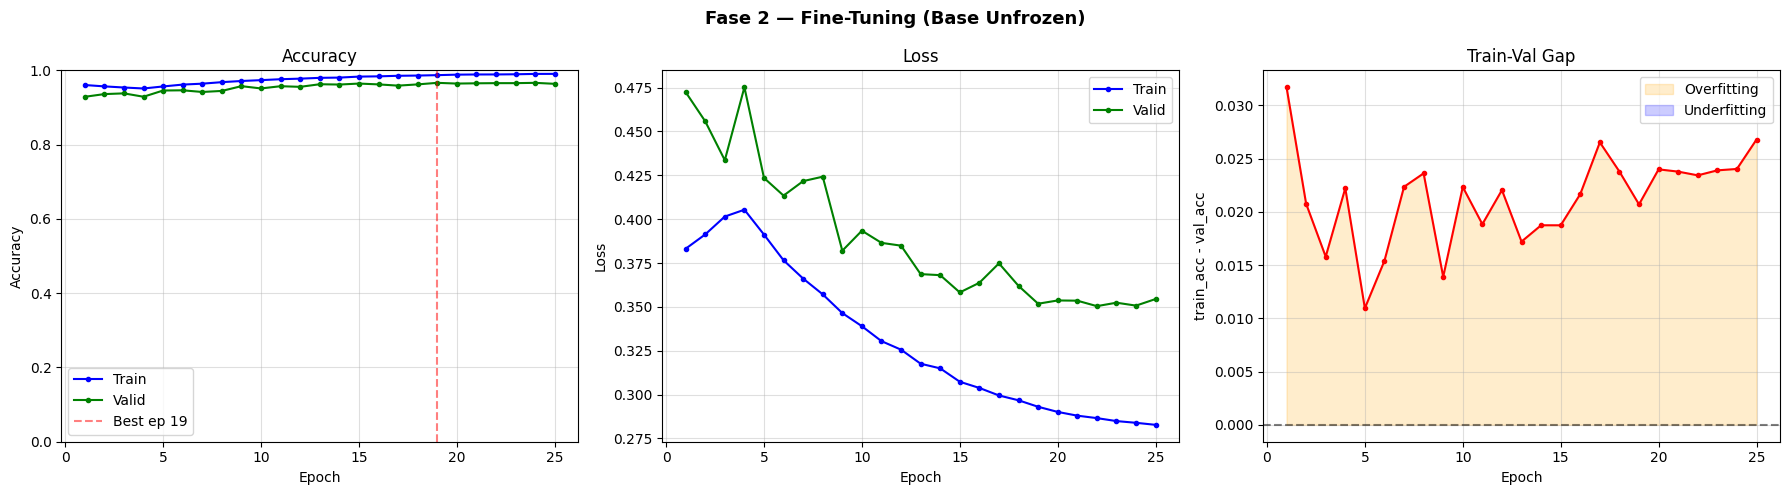

Best val_acc : 0.9663 @ epoch 19
Final gap    : +0.0268 (OK)


In [18]:
def plot_history(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    ep       = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(ep, acc,     'b-o', ms=3, label='Train')
    axes[0].plot(ep, val_acc, 'g-o', ms=3, label='Valid')
    best_e = int(np.argmax(val_acc)) + 1
    axes[0].axvline(best_e, color='r', linestyle='--', alpha=0.5, label=f'Best ep {best_e}')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    axes[0].legend(); axes[0].grid(True, alpha=0.4)

    # Loss
    axes[1].plot(ep, loss,     'b-o', ms=3, label='Train')
    axes[1].plot(ep, val_loss, 'g-o', ms=3, label='Valid')
    axes[1].set(title='Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

    # Gap (train - val) — monitor overfitting
    gap = [a - v for a, v in zip(acc, val_acc)]
    axes[2].plot(ep, gap, 'r-o', ms=3)
    axes[2].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[2].fill_between(ep, gap, 0,
                         where=[g > 0 for g in gap], alpha=0.2, color='orange', label='Overfitting')
    axes[2].fill_between(ep, gap, 0,
                         where=[g < 0 for g in gap], alpha=0.2, color='blue', label='Underfitting')
    axes[2].set(title='Train-Val Gap', xlabel='Epoch', ylabel='train_acc - val_acc')
    axes[2].legend(); axes[2].grid(True, alpha=0.4)

    plt.tight_layout(); plt.show()
    print(f"Best val_acc : {max(val_acc):.4f} @ epoch {best_e}")
    print(f"Final gap    : {gap[-1]:+.4f} ({'overfit' if gap[-1] > 0.05 else 'underfit' if gap[-1] < -0.02 else 'OK'})")

plot_history(history_phase2, "Fase 2 — Fine-Tuning (Base Unfrozen)")


## 14. Evaluasi TEST SET — Setelah Fine Tuning

Evaluasi TEST SET — Setelah Fine Tuning
224/224 [==============================] - 14s 52ms/step

Test Accuracy (setelah fine-tune): 0.9677

                               precision    recall  f1-score   support

           Anggur Busuk Hitam     0.9900    0.9900    0.9900       100
          Anggur Campak Hitam     0.9901    1.0000    0.9950       100
            Anggur Hawar Daun     1.0000    0.9900    0.9950       100
                 Anggur Sehat     1.0000    1.0000    1.0000       100
       Apel Bercak Alternaria     0.9798    0.9700    0.9749       100
          Apel Bercak Cokelat     1.0000    1.0000    1.0000       100
             Apel Busuk Hitam     0.9901    1.0000    0.9950       100
                   Apel Kudis     0.9900    0.9900    0.9900       100
                   Apel Sehat     0.9709    1.0000    0.9852       100
              Blueberry Sehat     0.9703    0.9800    0.9751       100
            Ceri Embun Tepung     1.0000    1.0000    1.0000       100
      

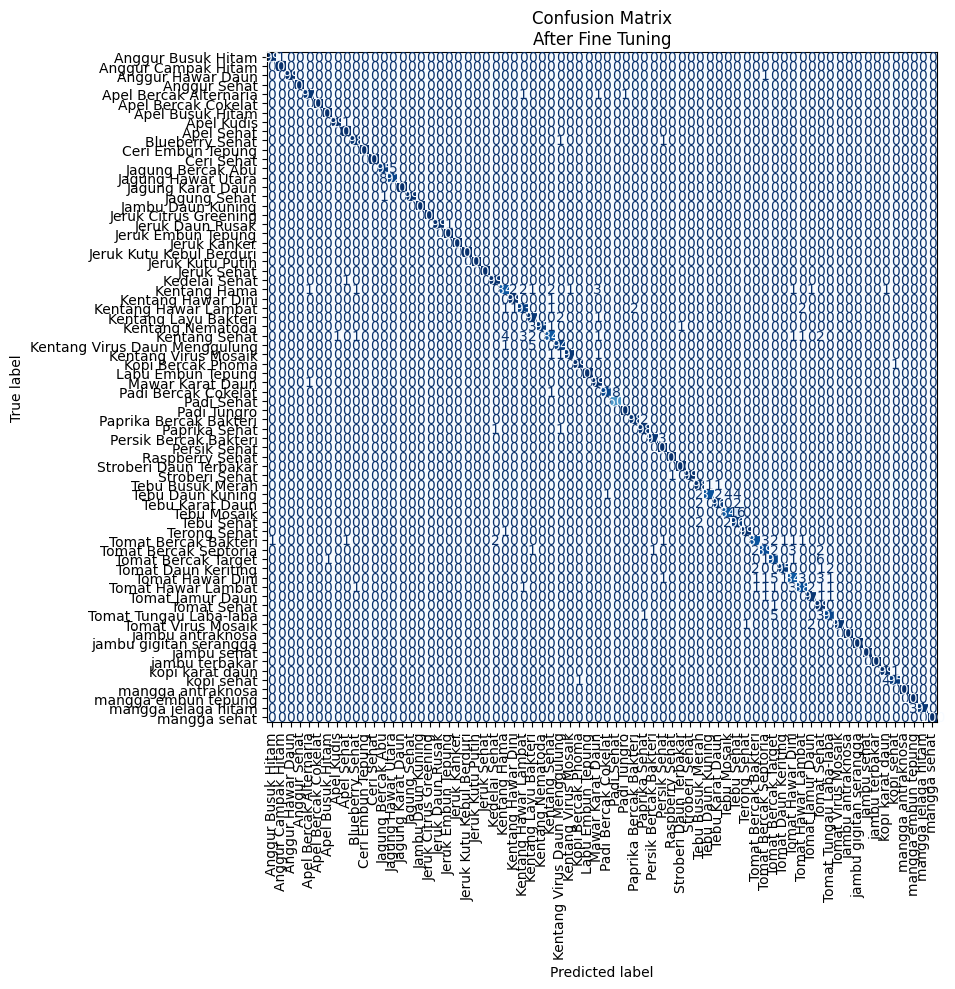

Accuracy Sebelum Fine Tuning : 0.9299
Accuracy Setelah Fine Tuning : 0.9677
Peningkatan Accuracy         : +0.0378
SEMUA HASIL BERHASIL DISIMPAN
Accuracy           : 0.9677374301675977
TXT Report         : C:\Users\crism\Music\New folder (5)\final_output\classification_report_after_finetune.txt
CSV Report         : C:\Users\crism\Music\New folder (5)\final_output\classification_report_after_finetune.csv
Confusion Matrix   : C:\Users\crism\Music\New folder (5)\final_output\confusion_matrix_after_finetune.png
Accuracy TXT       : C:\Users\crism\Music\New folder (5)\final_output\test_accuracy_after_finetune.txt


In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print('=' * 60)
print('Evaluasi TEST SET — Setelah Fine Tuning')
print('=' * 60)

# ------------------------------------------------------------
# Prediksi
# ------------------------------------------------------------
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Ground Truth
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------
acc_after = np.mean(y_true == y_pred)
print(f'\nTest Accuracy (setelah fine-tune): {acc_after:.4f}\n')

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

# ============================================================
# Simpan Classification Report (.txt)
# ============================================================
os.makedirs(SAVE_DIR, exist_ok=True)

txt_path = os.path.join(
    SAVE_DIR,
    'classification_report_after_finetune.txt'
)

with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('TEST SET - AFTER FINE TUNING\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Accuracy : {acc_after:.4f}\n\n')
    f.write(report)

# ============================================================
# Simpan Accuracy
# ============================================================
acc_path = os.path.join(
    SAVE_DIR,
    'test_accuracy_after_finetune.txt'
)

with open(acc_path, 'w') as f:
    f.write(f'Accuracy = {acc_after:.6f}')

# ============================================================
# Simpan Classification Report CSV
# ============================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

csv_path = os.path.join(
    SAVE_DIR,
    'classification_report_after_finetune.csv'
)

df_report.to_csv(csv_path)

# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    xticks_rotation=90,
    ax=ax,
    colorbar=False
)

plt.title('Confusion Matrix\nAfter Fine Tuning')
plt.tight_layout()

cm_path = os.path.join(
    SAVE_DIR,
    'confusion_matrix_after_finetune.png'
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Perbandingan Sebelum vs Sesudah Fine Tuning
# ============================================================
print('=' * 60)

try:
    improvement = acc_after - acc_before
    print(f'Accuracy Sebelum Fine Tuning : {acc_before:.4f}')
    print(f'Accuracy Setelah Fine Tuning : {acc_after:.4f}')
    print(f'Peningkatan Accuracy         : {improvement:+.4f}')
except NameError:
    print(f'Accuracy Setelah Fine Tuning : {acc_after:.4f}')

print('=' * 60)

# ============================================================
# Informasi File
# ============================================================
print('SEMUA HASIL BERHASIL DISIMPAN')
print('=' * 60)
print('Accuracy           :', acc_after)
print('TXT Report         :', txt_path)
print('CSV Report         :', csv_path)
print('Confusion Matrix   :', cm_path)
print('Accuracy TXT       :', acc_path)

## 15. Visualisasi Sebaran Fitur (t-SNE) — Test Set

Mengekstrak fitur dari layer 'feature_dense'...
224/224 [==============================] - 14s 54ms/step
Feature shape: (7160, 512)
Menjalankan t-SNE (mungkin 2-5 menit)...


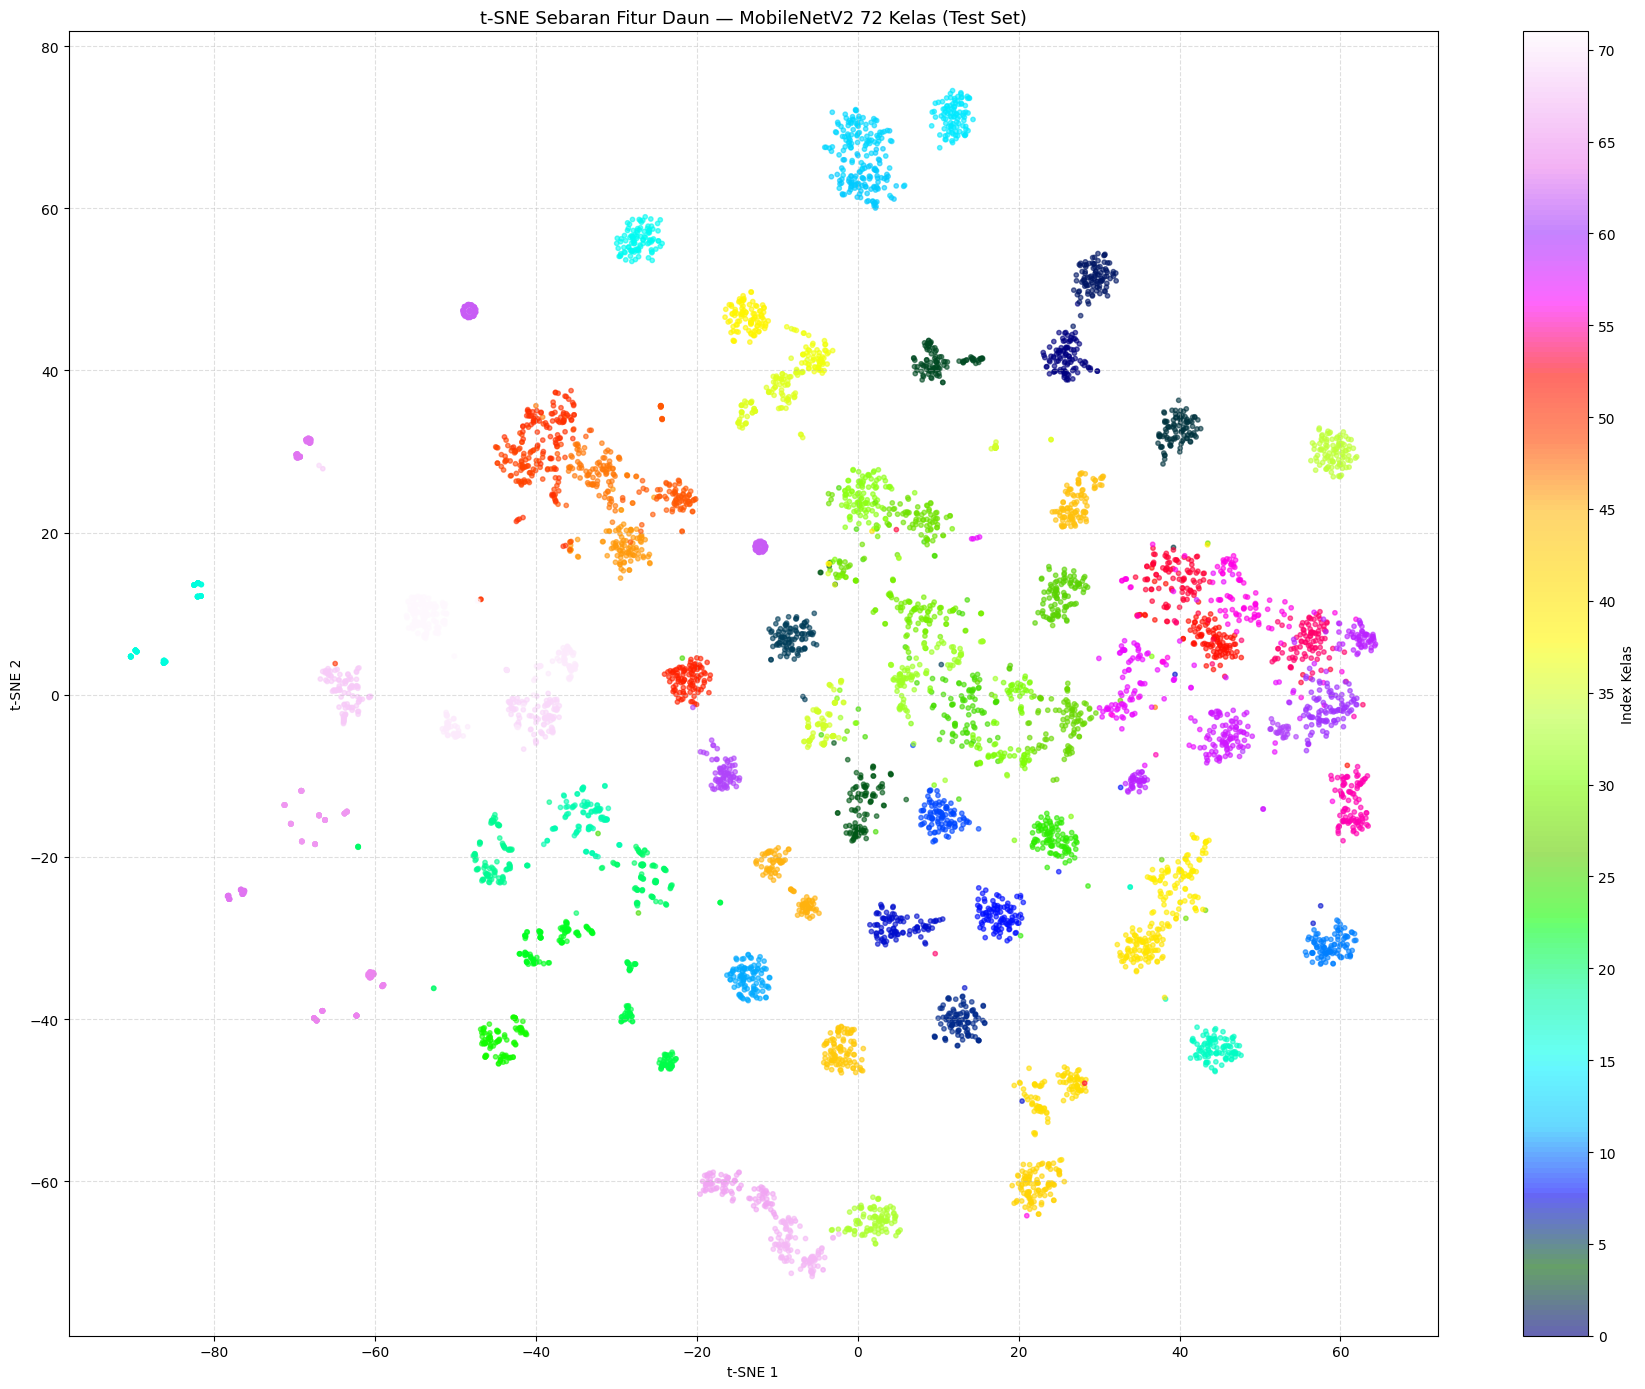

In [20]:
print("Mengekstrak fitur dari layer 'feature_dense'...")
feat_model = models.Model(inputs=model.input,
                          outputs=model.get_layer("feature_dense").output)
feats = feat_model.predict(test_ds)
print(f"Feature shape: {feats.shape}")

print("Menjalankan t-SNE (mungkin 2-5 menit)...")
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=1000)
X_tsne = tsne.fit_transform(feats)

plt.figure(figsize=(18, 14))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='gist_ncar', alpha=0.6, s=10)
cbar = plt.colorbar(sc, label='Index Kelas')
cbar.set_ticks(range(0, len(class_names), 5))
plt.title('t-SNE Sebaran Fitur Daun — MobileNetV2 72 Kelas (Test Set)', fontsize=13)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 18. Grad-CAM — Helper & Visualisasi

1/1 [==============================] - 3s 3s/step
Kelas Asli : Padi Bercak Cokelat
Prediksi   : Padi Bercak Cokelat (99.5%)


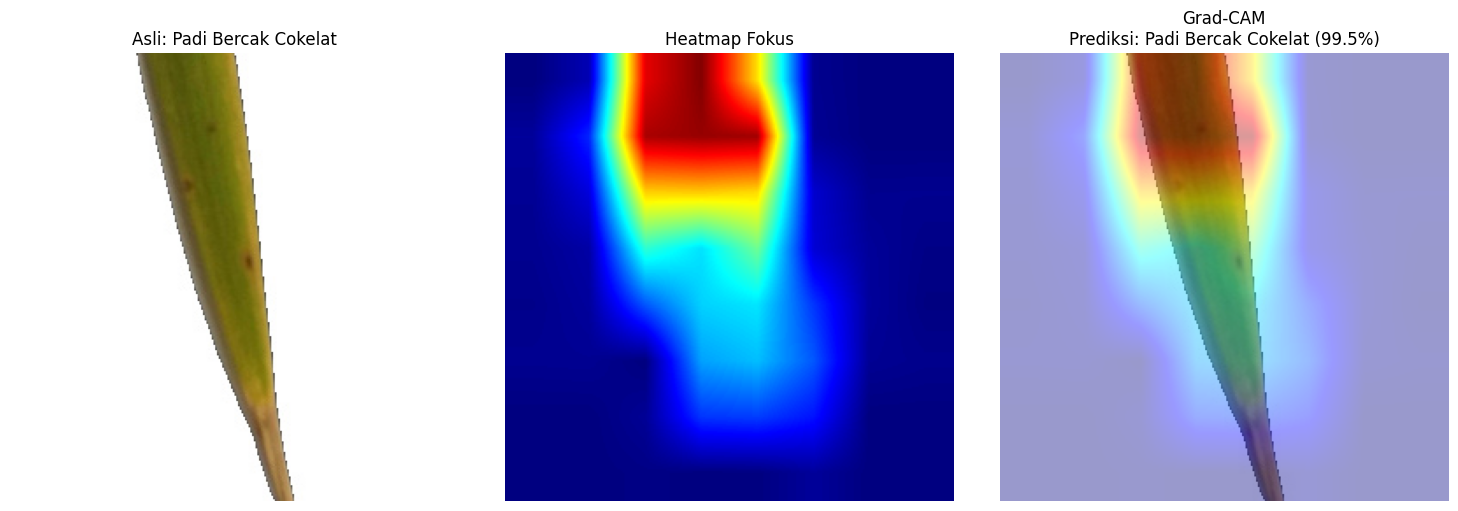

In [21]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="out_relu", pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img_orig        = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_orig        = cv2.resize(img_orig, IMG_SIZE)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.cvtColor(cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    superimposed    = cv2.addWeighted(img_orig, 1 - alpha, heatmap_color, alpha, 0)
    return img_orig, heatmap_color, superimposed

all_images = (glob.glob(os.path.join(TEST_DIR, "*", "*.jpg")) +
              glob.glob(os.path.join(TEST_DIR, "*", "*.jpeg")) +
              glob.glob(os.path.join(TEST_DIR, "*", "*.png")))

if all_images:
    rpath  = random.choice(all_images)
    img_l  = image.load_img(rpath, target_size=IMG_SIZE)
    img_a  = preprocess_input(np.expand_dims(image.img_to_array(img_l), 0))

    heatmap              = make_gradcam_heatmap(img_a, model, "out_relu")
    orig, heat, blended  = display_gradcam(rpath, heatmap)

    preds      = model.predict(img_a)
    pred_idx   = np.argmax(preds)
    pred_cls   = class_names[pred_idx]
    conf       = preds[0][pred_idx] * 100
    true_cls   = os.path.basename(os.path.dirname(rpath))

    print(f"Kelas Asli : {true_cls}")
    print(f"Prediksi   : {pred_cls} ({conf:.1f}%)")

    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(orig);             plt.title(f"Asli: {true_cls}");                               plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(heat, cmap='jet'); plt.title("Heatmap Fokus");                                   plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(blended);          plt.title(f"Grad-CAM\nPrediksi: {pred_cls} ({conf:.1f}%)"); plt.axis('off')
    plt.tight_layout(); plt.show()


## 19. Simpan Model & Label

In [22]:
save_path = os.path.join(SAVE_MODEL, "Leaf_Disease_MobileNetV2_FIXED_v3.keras")
model.save(save_path)
print(f"✅ Model disimpan : {save_path}")

label_out = os.path.join(SAVE_LABEL, "class_indices.json")
with open(label_out, "w") as f:
    json.dump(class_indices, f, indent=2)
print(f"✅ Label disimpan : {label_out}")
print()
print("Ringkasan output:")
print(f"  Model  : {save_path}")
print(f"  Label  : {label_out}")


✅ Model disimpan : C:\Users\crism\Music\New folder (5)\final_output\models\Leaf_Disease_MobileNetV2_FIXED_v3.keras
✅ Label disimpan : C:\Users\crism\Music\New folder (5)\final_output\labels\class_indices.json

Ringkasan output:
  Model  : C:\Users\crism\Music\New folder (5)\final_output\models\Leaf_Disease_MobileNetV2_FIXED_v3.keras
  Label  : C:\Users\crism\Music\New folder (5)\final_output\labels\class_indices.json
